## Imports

In [87]:
from tensorflow.keras import layers, models                                             # type: ignore
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from tensorflow.keras.optimizers import Adam                                            # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout                                # type: ignore

In [88]:
lead_time = 3

In [89]:
resolution = 11

## Read data

In [90]:
test_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/test-Dakar-map-features-many-timesteps-lt{lead_time}.csv", index_col=False)
test_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/test-Dakar-map-target-many-timesteps-lt{lead_time}.csv", index_col=False)

train_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/train-Dakar-map-features-many-timesteps-lt{lead_time}.csv", index_col=False)
train_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/train-Dakar-map-target-many-timesteps-lt{lead_time}.csv", index_col=False)

In [91]:
raw_test_X = test_data_X
raw_train_X, raw_validation_X, train_y, validation_y = train_test_split(train_data_X, train_data_y, test_size=0.3, random_state=12)

In [92]:
# Initial headers for time periods
t0 = "year,month,day,hour,minute,"
t15 = "year_15,month_15,day_15,hour_15,minute_15,"
t30 = "year_30,month_30,day_30,hour_30,minute_30,"
t45 = "year_45,month_45,day_45,hour_45,minute_45,"
t60 = "year_60,month_60,day_60,hour_60,minute_60,"

# Initialize empty strings for loc, wp, ds, sz for t0 (current), t15, t30, t45, and t60
loc = wp = ds = sz = "" 
loc_15 = wp_15 = ds_15 = sz_15 = "" 
loc_30 = wp_30 = ds_30 = sz_30 = "" 
loc_45 = wp_45 = ds_45 = sz_45 = "" 
loc_60 = wp_60 = ds_60 = sz_60 = "" 

# Loop to generate the string for each time period (current, +15, +30, +45, +60 minutes)
for i in range(1, 6):
    # For the current time (t0)
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    
    # For t15 (15 minutes later)
    loc_15 += f"lat{i}_15,lon{i}_15,"
    wp_15 += f"wp{i}_15,"
    ds_15 += f"ds{i}_15,"
    sz_15 += f"size{i}_15,"
    
    # For t30 (30 minutes later)
    loc_30 += f"lat{i}_30,lon{i}_30,"
    wp_30 += f"wp{i}_30,"
    ds_30 += f"ds{i}_30,"
    sz_30 += f"size{i}_30,"
    
    # For t45 (45 minutes later)
    loc_45 += f"lat{i}_45,lon{i}_45,"
    wp_45 += f"wp{i}_45,"
    ds_45 += f"ds{i}_45,"
    sz_45 += f"size{i}_45,"
    
    # For t60 (60 minutes later)
    loc_60 += f"lat{i}_60,lon{i}_60,"
    wp_60 += f"wp{i}_60,"
    ds_60 += f"ds{i}_60,"
    sz_60 += f"size{i}_60,"

# Concatenate all headers for t0, t15, t30, t45, t60
headers = (t0 + loc + wp + ds + sz + 
           t15 + loc_15 + wp_15 + ds_15 + sz_15 + 
           t30 + loc_30 + wp_30 + ds_30 + sz_30 + 
           t45 + loc_45 + wp_45 + ds_45 + sz_45 + 
           t60 + loc_60 + wp_60 + ds_60 + sz_60)

print(headers)


year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,lon3,lat4,lon4,lat5,lon5,wp1,wp2,wp3,wp4,wp5,ds1,ds2,ds3,ds4,ds5,size1,size2,size3,size4,size5,year_15,month_15,day_15,hour_15,minute_15,lat1_15,lon1_15,lat2_15,lon2_15,lat3_15,lon3_15,lat4_15,lon4_15,lat5_15,lon5_15,wp1_15,wp2_15,wp3_15,wp4_15,wp5_15,ds1_15,ds2_15,ds3_15,ds4_15,ds5_15,size1_15,size2_15,size3_15,size4_15,size5_15,year_30,month_30,day_30,hour_30,minute_30,lat1_30,lon1_30,lat2_30,lon2_30,lat3_30,lon3_30,lat4_30,lon4_30,lat5_30,lon5_30,wp1_30,wp2_30,wp3_30,wp4_30,wp5_30,ds1_30,ds2_30,ds3_30,ds4_30,ds5_30,size1_30,size2_30,size3_30,size4_30,size5_30,year_45,month_45,day_45,hour_45,minute_45,lat1_45,lon1_45,lat2_45,lon2_45,lat3_45,lon3_45,lat4_45,lon4_45,lat5_45,lon5_45,wp1_45,wp2_45,wp3_45,wp4_45,wp5_45,ds1_45,ds2_45,ds3_45,ds4_45,ds5_45,size1_45,size2_45,size3_45,size4_45,size5_45,year_60,month_60,day_60,hour_60,minute_60,lat1_60,lon1_60,lat2_60,lon2_60,lat3_60,lon3_60,lat4_60,lon4_60,lat5_60,lon5_60,wp1_60,wp2_60,wp3_60

## Preprocessing

In [93]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [94]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [95]:
to_scale = f"{wp}{wp_15}{wp_30}{wp_45}{wp_60}{sz}{sz_15}{sz_30}{sz_45}{sz_60}{ds}{ds_15}{ds_30}{ds_45}{ds_60}".rstrip(',')

In [96]:
t = f"{t0}{t15}{t30}{t45}{t60}".rstrip(',')

In [97]:
def prepare(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t.split(',')[:-1])
    return df

### Transforming

In [98]:
transform = True
if transform:
    train_X = prepare(raw_train_X)
    validation_X = prepare(raw_validation_X)
    test_X = prepare(raw_test_X)

### Scaling

In [99]:
scaler = StandardScaler()
std_X_train = scaler.fit_transform(train_X)
std_X_val = scaler.transform(validation_X)
std_X_test = scaler.transform(test_X)

In [100]:
x_train = std_X_train.reshape(len(train_X), 5, 30)
y_train = tf.reshape(train_y, (len(train_y), resolution, resolution))

x_val = std_X_val.reshape(len(validation_X), 5, 30)
y_val = tf.reshape(validation_y, (len(validation_y), resolution, resolution))

x_test = std_X_test.reshape(len(test_X), 5, 30)
y_test = tf.reshape(test_data_y, (len(test_data_y), resolution, resolution))

In [101]:
y_test.shape

TensorShape([12456, 11, 11])

### Creating the model 

In [102]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(5, 30)),
  LSTM(20, activation="relu"),
  tf.keras.layers.Dense(32, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dense(resolution * resolution, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution, 1)),
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution)),
])

In [103]:
cl_thresholds = 0.15

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]

In [104]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)

In [105]:
"""l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:  
  layer.kernel_regularizer = l1_reg"""

'l1_reg = tf.keras.regularizers.L1(0.1)\nfor layer in model.layers[:]:  \n  layer.kernel_regularizer = l1_reg'

In [106]:
optimizer = Adam(clipvalue=1.0, learning_rate=1e-3)
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.AUC(name='prc', curve='PR')])

In [107]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20)             │         4,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 121)            │         3,993 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 11, 11, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 1)      │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 11, 11)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,098 (35.54 KB)

 Trainable params: 9,098 (35.54 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=500,                           
                          batch_size = 1024,         
                          callbacks = [early_stopping],
                          validation_data=(x_val, y_val)
                        )

Epoch 1/500


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.5045 - prc: 0.1975 - val_loss: 0.3927 - val_prc: 0.3167
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.3822 - prc: 0.3303 - val_loss: 0.3674 - val_prc: 0.3630
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.3651 - prc: 0.3628 - val_loss: 0.3584 - val_prc: 0.3875
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.3567 - prc: 0.3953 - val_loss: 0.3522 - val_prc: 0.4102
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.3495 - prc: 0.4188 - val_loss: 0.3472 - val_prc: 0.4278
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.3483 - prc: 0.4367 - val_loss: 0.3432 - val_prc: 0.4413
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.3413 - prc: 0.4468 - val_loss: 0.3400 - val_prc: 0.4512
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.3378 - prc: 0.4584 - val_loss: 0.3373 - val_prc: 0.4589
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.3351 -

### Save model

In [109]:
dump(scaler, f'Dakar-map-lt{lead_time}-lstm.bin', compress=True)
model.save(f'Dakar-map-lt{lead_time}-lstm.keras')

In [110]:
n_test = test_data_y.shape[0]

In [111]:
pred_y_train = model.predict(x_train).flatten()
pred_y_test = model.predict(x_test).flatten()

1022/1022 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [112]:
idx = []

for i in range(y_test.shape[0]):
    idx.append(np.mean(y_test[i]))

In [113]:
idx_max = np.argmax(idx)

In [114]:
y_test[idx_max]

<tf.Tensor: shape=(11, 11), dtype=float64, numpy=
array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])>

In [115]:
raw_test_X.iloc[idx_max, :]

year      2020.00
month        9.00
day          5.00
hour        21.00
minute      15.00
           ...   
ds1_60      21.47
ds2_60      40.52
ds3_60      46.49
ds4_60      49.98
ds5_60      52.43
Name: 2997, Length: 150, dtype: float64

In [116]:
pred_y_test.reshape(n_test, resolution, resolution)[idx_max]

array([[0.21931899, 0.24622917, 0.33803475, 0.47166705, 0.46898252,
        0.51069903, 0.45027083, 0.49904034, 0.4697537 , 0.4196341 ,
        0.4309166 ],
       [0.24135147, 0.3047658 , 0.45366904, 0.5079272 , 0.501297  ,
        0.56174815, 0.5544851 , 0.5550399 , 0.5297571 , 0.45621955,
        0.4393531 ],
       [0.3567495 , 0.37846676, 0.5424362 , 0.6420388 , 0.63700205,
        0.66820145, 0.7198002 , 0.732633  , 0.69055474, 0.5650305 ,
        0.55348283],
       [0.3633821 , 0.39232123, 0.5071255 , 0.6900938 , 0.73380375,
        0.75151956, 0.71647334, 0.73092884, 0.6916723 , 0.57692647,
        0.568441  ],
       [0.36338666, 0.38576648, 0.5131937 , 0.62177473, 0.7565051 ,
        0.78678066, 0.76633805, 0.7589658 , 0.7297862 , 0.59205663,
        0.5247013 ],
       [0.4183305 , 0.47115368, 0.5668244 , 0.68149555, 0.7986528 ,
        0.7929085 , 0.7891976 , 0.76655203, 0.7653426 , 0.59577096,
        0.54005814],
       [0.34980506, 0.45464927, 0.5947499 , 0.7053889 , 0.

## ROC

In [117]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [118]:
auc_train = roc_auc_score(y_train.numpy().flatten(), pred_y_train)
auc_test = roc_auc_score(y_test.numpy().flatten(), pred_y_test)

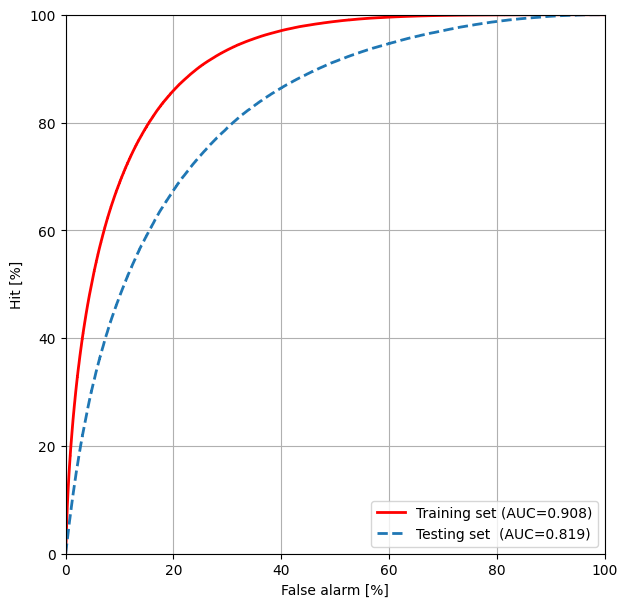

In [119]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train.numpy().flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test.numpy().flatten(), pred_y_test.flatten(), color=colors[0], linestyle='--')
plt.legend(loc='lower right');

## Reliability diagram

In [120]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

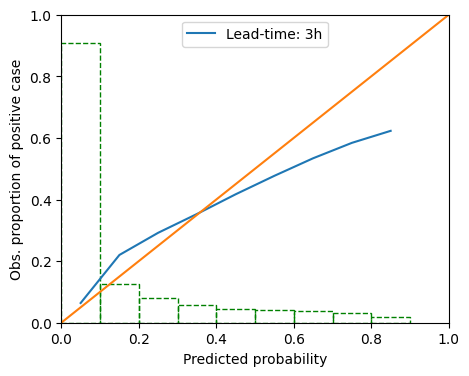

In [131]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.numpy().flatten(), pred_y_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"Lead-time: {lead_time}h")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

## Plotting

In [122]:
import cartopy.crs as ccrs                              # type: ignore
import cartopy.feature as cfeature                      # type: ignore
import warnings
warnings.filterwarnings("ignore")
from netCDF4 import Dataset                             # type: ignore

In [123]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [124]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xlimit = 1803
ylimit = 556

lons = geodata["lons_mid"][:ylimit, :xlimit]
lats = geodata["lats_mid"][:ylimit, :xlimit]

In [125]:
original_y_min, original_x_min = nflics.X0(13, -18)
original_y_max, original_x_max = nflics.X0(16, -15)

# To fix dimensions

y_min = original_y_min - 2
y_max = original_y_max + 2
x_min = original_x_min 
x_max = original_x_max + 1

In [126]:
def downsample_grid(grid, factor):
    # Ensure that the grid dimensions are divisible by the factor
    assert grid.shape[0] % factor == 0
    assert grid.shape[1] % factor == 0

    # Reshape the grid to factor blocks and then take the mean
    grid_downsampled = grid.reshape(grid.shape[0] // factor, factor,
                                    grid.shape[1] // factor, factor).mean(axis=(1, 3))
    
    return grid_downsampled

def create_lat_lon_grid(latitudes, longitudes, factor):
    lat_min = latitudes.min()
    lat_max = latitudes.max()
    lon_min = longitudes.min()
    lon_max = longitudes.max()
    
    num_rows = latitudes.shape[0] // factor
    num_cols = longitudes.shape[1] // factor
    
    new_lats = np.linspace(lat_min, lat_max, num_rows)
    new_lons = np.linspace(lon_min, lon_max, num_cols)
    
    new_latitudes, new_longitudes = np.meshgrid(new_lats, new_lons, indexing='ij')
    
    return new_latitudes, new_longitudes

In [127]:
if resolution == 11:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 10)
else:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 5)

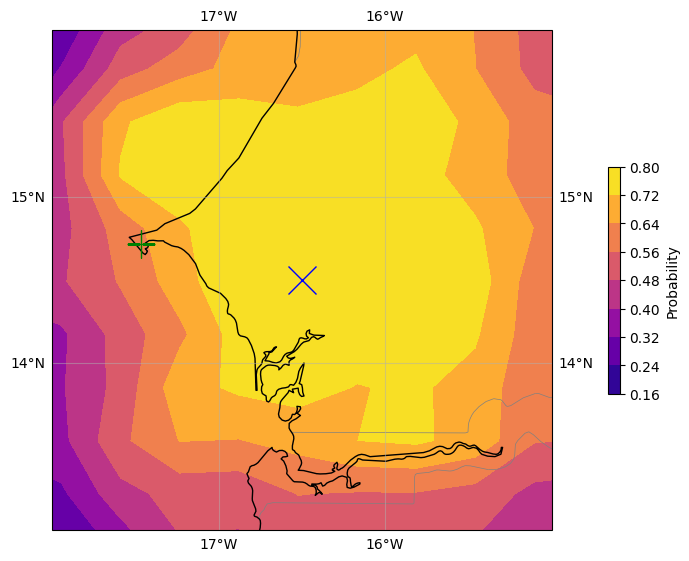

In [128]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

contour_core = ax.contourf(downsampled_lons, downsampled_lats, pred_y_test.reshape(n_test, resolution, resolution)[idx_max], transform=ccrs.PlateCarree(), cmap="plasma")
plt.colorbar(contour_core, label="Probability", fraction=0.02, pad=0.1)

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

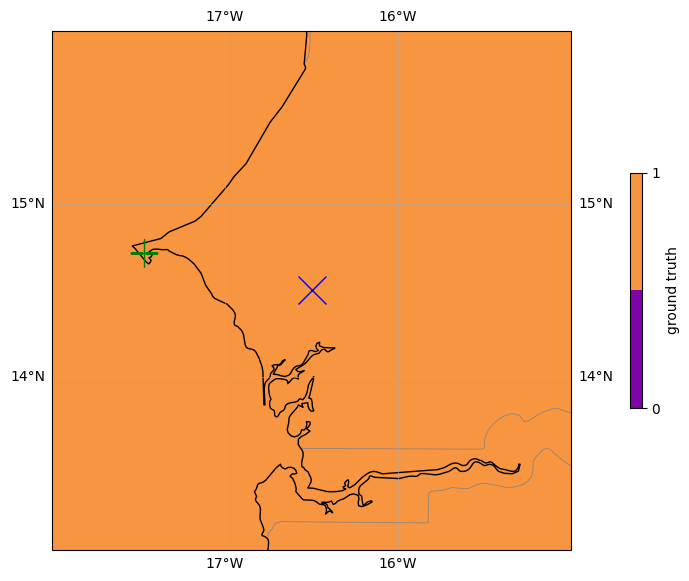

In [129]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

levels = [0, 0.5, 1]

contour_core = ax.contourf(downsampled_lons, downsampled_lats, y_test[idx_max], transform=ccrs.PlateCarree(), cmap="plasma", levels=levels)
cbar = plt.colorbar(contour_core, label="ground truth", fraction=0.02, pad=0.1)

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

In [130]:
#model.save(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/Dakar-map-t{lead_time}.keras')